### 1. Load Data & Preprocessing

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("CSV_FOR_MODEL.csv")
unneccessary_cols = ['tmdb_id', 'title',  'overview', 'original_language', 'genre_names', 'primary_country','language_count', 
                    'lead_actor_name', 'director_name', 'num_directors','representation_tier', 'genre_crime', 'genre_action', 
                     'genre_documentary', 'genre_fantasy', 'genre_drama','genre_tv_movie', 'genre_family', 'genre_animation',
                     'genre_music','genre_thriller', 'genre_history', 'genre_adventure', 'genre_science_fiction', 'genre_mystery',
                     'genre_horror', 'genre_war', 'genre_romance', 'genre_comedy', 'genre_western', 'primary_genre', 'primary_company', 
                     'release_date', "decade"]
clean_df = df.drop(columns = unneccessary_cols)
clean_df = clean_df[clean_df["lead_gender"].isin([1.0, 2.0])]
clean_df = clean_df[clean_df["director_gender"].isin([1.0, 2.0])]

### Feature processing & engineering

In [3]:
X = clean_df.drop(columns = ['genre_5class'])
y = clean_df['genre_5class']

# Fet rid of raw counts for features
X = X.drop(columns=["top5_female", "top5_male", "cast_female", "cast_male", "cast_total_known","female_writers", "female_producers", "vote_count"])
print(X.describe())

       release_year    popularity  vote_average   lead_gender  lead_actor_age  \
count  17826.000000  17826.000000  17826.000000  17826.000000    17826.000000   
mean    2015.337316      2.775074      6.303647      1.639571       38.682935   
std        5.209565      3.351252      0.874679      0.480138       16.192433   
min     2005.000000      0.006200      1.900000      1.000000      -17.000000   
25%     2011.000000      1.266925      5.794000      1.000000       29.000000   
50%     2016.000000      1.947650      6.352500      2.000000       38.000000   
75%     2019.000000      3.123150      6.900000      2.000000       48.000000   
max     2024.000000    142.791500      9.900000      2.000000      137.000000   

       pct_female_top5  pct_female_cast  director_gender  director_age  \
count     17826.000000     17826.000000     17826.000000  17826.000000   
mean          0.398987         0.373205         1.876024     36.396780   
std           0.226239         0.171132         

In [4]:
# Log transform skewed features
X['popularity'] = np.log1p(X['popularity'])

# Get rid of weird outliers in age
X["lead_actor_age"] = X["lead_actor_age"].clip(0, 100)

# Change to binary indicator bc most films have 0% 
X["has_female_writers"] = (X["pct_female_writers"] > 0).astype(int)
X["has_female_producers"] = (X["pct_female_producers"] > 0).astype(int)

# Change gender columns to binary (female: 1 -> 0 and male: 2 -> 1
X["lead_gender"] = X["lead_gender"].map({1.0: 0, 2.0: 1})
X["director_gender"] = X["director_gender"].map({1.0: 0, 2.0: 1})

# Transform release_year
X["years_since_2005"] = X["release_year"] - 2005

X = X.drop(columns= ['release_year','pct_female_writers', 'pct_female_producers'])

print(X.describe())

         popularity  vote_average   lead_gender  lead_actor_age  \
count  17826.000000  17826.000000  17826.000000    17826.000000   
mean       1.165887      6.303647      0.639571       38.676259   
std        0.506233      0.874679      0.480138       16.155150   
min        0.006181      1.900000      0.000000        0.000000   
25%        0.818424      5.794000      0.000000       29.000000   
50%        1.081008      6.352500      1.000000       38.000000   
75%        1.416617      6.900000      1.000000       48.000000   
max        4.968364      9.900000      1.000000      100.000000   

       pct_female_top5  pct_female_cast  director_gender  director_age  \
count     17826.000000     17826.000000     17826.000000  17826.000000   
mean          0.398987         0.373205         0.876024     36.396780   
std           0.226239         0.171132         0.329564     22.043574   
min           0.000000         0.000000         0.000000      0.000000   
25%           0.200000    

### 2. Logistic Regression Model

In [5]:
# Encode y
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split, train
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Standardize numeric features
scale_cols = ["popularity","vote_average","lead_actor_age","director_age",]
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

C:\Users\looan\anaconda3\envs\ds3000\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.41492146596858637

Classification Report:
               precision    recall  f1-score   support

      Action       0.62      0.45      0.52      1961
      Comedy       0.37      0.26      0.31      1077
       Drama       0.38      0.44      0.41      1027
      Horror       0.32      0.56      0.41       582
     Romance       0.29      0.40      0.34       701

    accuracy                           0.41      5348
   macro avg       0.40      0.42      0.40      5348
weighted avg       0.45      0.41      0.42      5348



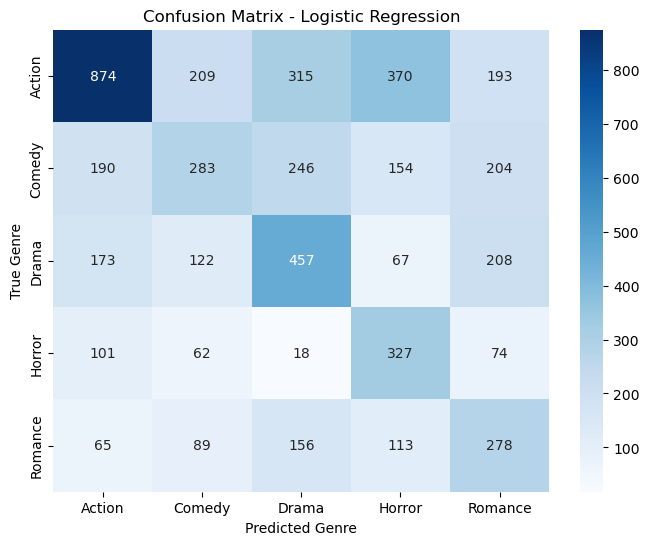

In [6]:
# Base Model
logreg = LogisticRegression(max_iter=5000, multi_class="multinomial", class_weight="balanced")
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [7]:
# Feature Importance (based on coefficients)
feature_names = X_train.columns
coef_df = pd.DataFrame(logreg.coef_, columns=feature_names,index=le.classes_)

for genre in coef_df.index:
    print("\n", genre)
    print(coef_df.loc[genre].sort_values(ascending=False).head(5))


 Action
popularity          0.445492
director_gender     0.248381
lead_gender         0.223390
lead_actor_age      0.036118
years_since_2005    0.020930
Name: Action, dtype: float64

 Comedy
pct_female_cast       0.421713
lead_gender           0.387770
has_female_writers    0.228998
lead_actor_age        0.193317
vote_average          0.054030
Name: Comedy, dtype: float64

 Drama
vote_average            0.774500
director_age            0.264104
has_female_producers    0.242709
lead_actor_age          0.191201
pct_female_top5         0.072391
Name: Drama, dtype: float64

 Horror
pct_female_cast     0.753057
director_gender     0.532495
pct_female_top5     0.477697
popularity          0.410704
years_since_2005    0.035743
Name: Horror, dtype: float64

 Romance
pct_female_cast         1.779916
has_female_writers      0.525624
vote_average            0.243285
has_female_producers    0.196543
director_age            0.015512
Name: Romance, dtype: float64


In [8]:
# Global feature importance
global_importance = coef_df.abs().mean().sort_values(ascending=False)
print(global_importance)

pct_female_cast         1.181875
vote_average            0.428726
popularity              0.342478
has_female_writers      0.324109
director_gender         0.312351
lead_gender             0.244464
pct_female_top5         0.220035
has_female_producers    0.175701
lead_actor_age          0.168254
director_age            0.127323
years_since_2005        0.022669
dtype: float64


### With Regularization

In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

logreg = LogisticRegression(max_iter=5000, multi_class="multinomial",class_weight="balanced")

grid = GridSearchCV(logreg, param_grid, scoring="f1_macro", cv=5, n_jobs=-1)

grid.fit(X_train, y_train)

print("Best C:", grid.best_params_["C"])
print("Best CV Macro F1:", grid.best_score_)

best_model = grid.best_estimator_

C:\Users\looan\anaconda3\envs\ds3000\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best C: 100
Best CV Macro F1: 0.3955399278713174


In [17]:
y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred, target_names=le.classes_
))

Test Accuracy: 0.4151084517576664

Classification Report:
               precision    recall  f1-score   support

      Action       0.62      0.45      0.52      1961
      Comedy       0.37      0.26      0.31      1077
       Drama       0.38      0.44      0.41      1027
      Horror       0.32      0.56      0.40       582
     Romance       0.29      0.40      0.34       701

    accuracy                           0.42      5348
   macro avg       0.40      0.42      0.40      5348
weighted avg       0.45      0.42      0.42      5348



### 3. Neural Network - Multilayer perceptron

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

X_train_nn = X_train.copy()
X_test_nn = X_test.copy()

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_nn.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_nn.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True) #batching- how much data the model sees at once

In [15]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train_tensor.shape[1]
num_classes = len(le.classes_)

hidden_sizes = [64, 128]
learning_rates = [0.001, 0.003, 0.0005]

best_acc = 0
best_config = None

# Training loop
for hidden_size in hidden_sizes:
    for lr in learning_rates:

        print(f"\nTraining model: hidden={hidden_size}, lr={lr}")

        model = MLP(input_size, hidden_size, num_classes)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        epochs = 100

        for epoch in range(epochs):
            model.train()
            total_loss = 0

            for X_batch, y_batch in train_loader:
                optimizer.zero_grad() # clear old gradients
                outputs = model(X_batch) # make predictions
                loss = criterion(outputs, y_batch) # compute loss
                loss.backward() #compute gradient/how to adjust weight
                optimizer.step() # update weights
                total_loss += loss.item()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(train_loader):.4f}")
        # Evaluate        
        model.eval()
        with torch.no_grad():
            outputs = model(X_test_tensor)
            predictions = torch.argmax(outputs, dim=1)
            acc = (predictions == y_test_tensor).float().mean().item()

        print(f"Test accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_config = (hidden_size, lr)

print("\n====================")
print(f"Best accuracy: {best_acc:.4f}")
print(f"Best config: hidden={best_config[0]}, lr={best_config[1]}")
print("====================")


Training model: hidden=64, lr=0.001
Epoch 10/100 — Loss: 1.2905
Epoch 20/100 — Loss: 1.2697
Epoch 30/100 — Loss: 1.2589
Epoch 40/100 — Loss: 1.2513
Epoch 50/100 — Loss: 1.2471
Epoch 60/100 — Loss: 1.2412
Epoch 70/100 — Loss: 1.2374
Epoch 80/100 — Loss: 1.2353
Epoch 90/100 — Loss: 1.2312
Epoch 100/100 — Loss: 1.2298
Test accuracy: 0.4671

Training model: hidden=64, lr=0.003
Epoch 10/100 — Loss: 1.2729
Epoch 20/100 — Loss: 1.2524
Epoch 30/100 — Loss: 1.2423
Epoch 40/100 — Loss: 1.2299
Epoch 50/100 — Loss: 1.2250
Epoch 60/100 — Loss: 1.2200
Epoch 70/100 — Loss: 1.2166
Epoch 80/100 — Loss: 1.2122
Epoch 90/100 — Loss: 1.2112
Epoch 100/100 — Loss: 1.2076
Test accuracy: 0.4688

Training model: hidden=64, lr=0.0005
Epoch 10/100 — Loss: 1.3195
Epoch 20/100 — Loss: 1.2962
Epoch 30/100 — Loss: 1.2813
Epoch 40/100 — Loss: 1.2705
Epoch 50/100 — Loss: 1.2637
Epoch 60/100 — Loss: 1.2587
Epoch 70/100 — Loss: 1.2543
Epoch 80/100 — Loss: 1.2503
Epoch 90/100 — Loss: 1.2480
Epoch 100/100 — Loss: 1.2450
T